<font color=#009afa size=50>[Project Title]</font><br>
<font size=50>[Project Subtitle]</font><br>
<font size=20 color=#00c382>1 - Data Exploration and Cleaning</font><br>

|**Assessment Code:** |[Code]|
|---|---|
|**Author:**|[Author(s)]|
|**Course:**|[Course Code]|
|**Course Tutor:**|[Supervisor]|


**Coding Syntax Note: _variable_name --> temporary / locally used variable, discarded after use.**


---

# Initialise Notebook

In [1]:
# Install Requirements Using Pip
%pip install -r requirements.txt

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (37 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.1.4-py3-none-any.whl.metadata (2.5 kB)
  Using cached scipy-1.17.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached setuptools-82.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached websocket_client-1.9.0-py3-none-any

### Import Python Libraries

In [2]:
# Standard Libraries
import sys
import time
import json
import random
from datetime import datetime

# Pandas and numpy
import pandas as pd
import numpy as np

# Matplot Lib
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.pyplot import figure
import matplotlib.ticker as mticker
import matplotlib.animation as animation
%matplotlib inline

# Seaborn Graphs
import seaborn as sns

# Tabulate
from tabulate import tabulate

# Colorama
from colorama import Fore, Back, Style

# Requests
import requests

# Pycountry 
import pycountry

# GeoPy
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Cartopy Maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geopandas
import geopandas as gpd

# IPython Display 
from IPython.display import HTML

# NetworkX
import networkx as nx

# Do not print warnings!
import warnings
warnings.filterwarnings('ignore')

### Create a Timestamp

In [3]:
# Generate Timestamp
today = pd.Timestamp(datetime.today())
now_date_timestamp = str(today.strftime("%Y%m%d"))
now_datetime_timestamp = str(today.strftime("%Y%m%d-%H%M"))

### Functions for Pretty Output

print_output - Print coloured Output

In [4]:
# Function to print coloured output
def print_output (str1, str2, delim=':', colour='yellow'):
    if colour.upper() in dir(Fore):
        colour = colour.upper()
    else:
        colour = 'YELLOW'
    print (f'{getattr(Fore, colour)}{str(str1)}{delim}{Style.RESET_ALL} {str(str2)}')

string_padding - Custom padding function

In [5]:
# Adds string padding to a string (left or right side)
def string_padding (a_string, length,side="right"):
    if len(a_string) < length:
        # Pad the string with spaces
        if side == "left":
            # Pad on the left
            return " " * (length - len(a_string)) + a_string        
        else:
            return a_string + " " * (length - len(a_string))    
    else:
        # Truncate the string to the specified length
        return a_string[:length]
    


print_results_table - Create a custom results table

In [6]:
# Print Results Table
def print_results_table (results, table_title = "Results", padding=16):

    # Set the padding value
    padding_value = padding

    if len(results) < 1:
        print (Fore.RED + "No results found" + Style.RESET_ALL)
    else:
        print ("")
        print (Fore.YELLOW + table_title + Style.RESET_ALL)

        header_fields = list(results[0].keys())

        header_row = ""
        for f in header_fields:
            #header_row = string_padding(f, len(str(results[0][f])),side='left')
            header_row += string_padding(f, padding_value,side='left')
        print ((len(header_row)+2) * "-")
        print (header_row)
        print ((len(header_row)+2) * "-")

        # Print each row of the results in alternating stripes
        row_count = 0
        for row in results:
            row_str = ""
            for f in header_fields:
                row_str += string_padding(str(row[f]), padding_value,side='left')
            if row_count % 2 == 0:
                print (Fore.CYAN + row_str + Style.RESET_ALL)
            else:   
                print (Fore.WHITE + row_str + Style.RESET_ALL)
            row_count += 1

        print ((len(header_row)+2) * "-")
        print ("Total Results: ", len(results))
        print ((len(header_row)+2) * "-")
        print ("")

### Check for Internet Access

In [7]:
_urls_to_check = ['http://connectivitycheck.gstatic.com/generate_204',
                  'https://www.github.com',
                  'https://datascience.daemonchild.com']

Set this to False if you have a local dataset

In [8]:
internet_required = False

In [9]:
# Function to Safely Check for Internet Connectivity
def check_internet (url_list):
    online = False
    for _url in url_list:
        try:
            response = requests.get(_url, timeout=3)
            if response.status_code == 200:
                online = True
                break
        except requests.RequestException:
            output_string = f"Check Internet failed for {_url}"
            print_output ('[FAIL]',output_string, colour='red', delim='')
    return online

# Perform the checks
if check_internet (_urls_to_check ):
    print_output ('[INTERNET]','Internet Connectivity Detected. Using Internet resources.',colour='green', delim='')
    online = True

else:
    print ()
    print_output ('[INTERNET]','No Internet Connectivity.', colour='red', delim='')
    online = False


# Stop running if Internet is required
if online == False & internet_required == True:
    sys.exit('Stopping notebook run here.')    


[INTERNET] Internet Connectivity Detected. Using Internet resources.


---
# Define Semantic Network Class

In [ ]:
class SemanticNetwork:
    def __init__(self, root_node="RootNode"):
        self.G = nx.DiGraph()
        self.root = root_node
        self.palette = {0:"#181F1C", 1:"#274029", 2:"#315C2B", 3:"#60712F", 4:"#9EA93F", 5:"#4C4C45", 6:"#96978F"}

    def add_relation(self, child, parent, relation_type="IS-A"):
        """Adds structural hierarchy links."""
        self.G.add_edge(child, parent, label=relation_type)

    def add_property(self, node, value, property_name):
        """Adds attribute/data links."""
        self.G.add_edge(node, value, label=property_name)

    def get_inherited_attribute(self, node, attribute_label):
        """Climbs the IS-A tree to find properties, supporting overrides."""
        current = node
        while current:
            # Check current node for the specific property
            for _, neighbor, data in self.G.out_edges(current, data=True):
                if data.get('label') == attribute_label:
                    return neighbor
            # Climb up the hierarchy
            parents = [target for _, target, data in self.G.out_edges(current, data=True) 
                       if data.get('label') in ["IS-A", "INSTANCE-OF"]]
            current = parents[0] if parents else None
        return "N/A"

    def get_node_level(self, node):
        """Calculates distance from the root node."""
        try:
            return nx.shortest_path_length(self.G.to_undirected(), source=node, target=self.root)
        except:
            return None

    def export_to_json(self, filename="network.json"):
        """Exports the graph structure to a JSON file."""
        data = nx.node_link_data(self.G)
        with open(filename, 'w') as f:
            json.dump(data, f, indent=4)
        print(f"Successfully exported to {filename}")

    def draw(self):
        """Visualizes the network using a structured top-down layout."""
        # Calculate positions based on levels
        dist = {n: self.get_node_level(n) for n in self.G.nodes() if self.get_node_level(n) is not None}
        pos = {}
        level_counts = {}
        for node, level in dist.items():
            level_counts[level] = level_counts.get(level, 0) + 1
            pos[node] = (level_counts[level] * 5, -level * 2)

        # Color nodes by level
        colors = [self.palette.get(dist.get(n, 0), "#D3D3D3") for n in self.G.nodes()]
        
        plt.figure(figsize=(12, 8))
        nx.draw(self.G, pos, with_labels=True, node_color=colors, 
                node_size=3000, font_size=8, font_weight='bold', edge_color='gray')
        
        labels = nx.get_edge_attributes(self.G, 'label')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=labels, font_size=7, font_color='red')
        plt.title(f"Semantic Network: {self.root} Hierarchy")
        plt.show()

    def generate_report(self):
        """Compiles a summary table of all concepts and inherited data."""
        report_data = []
        # Filter for 'Concept' nodes (those with a hierarchical level)
        concept_nodes = [n for n in self.G.nodes() if self.get_node_level(n) is not None]
        
        for node in concept_nodes:
            report_data.append({
                "Entity": node,
                "Level": self.get_node_level(node),
                "Damage": self.get_inherited_attribute(node, "causesDamage"),
                "Material": self.get_inherited_attribute(node, "primaryMaterial"),
                "Origin": self.get_inherited_attribute(node, "historicalOrigin")
            })
        return pd.DataFrame(report_data).sort_values("Level")


                  Entity  Level    Damage Material Origin
1                 Weapon      0       N/A      N/A    N/A
0                  Melee      1       N/A      N/A    N/A
2                 Ranged      1       N/A      N/A    N/A
3                 Bladed      2       Cut    Steel    N/A
4                  Blunt      2       N/A      N/A    N/A
5                Polearm      2       N/A      N/A    N/A
6              Francisca      2       N/A      N/A    N/A
7                Javelin      2       N/A      N/A    N/A
8                    Bow      2       N/A      N/A    N/A
9               Arbalest      2       N/A      N/A    N/A
10                   Gun      2       N/A      N/A    N/A
11             Artillery      2       N/A      N/A    N/A
12                 Sword      3       Cut    Steel    N/A
13                Dagger      3  Puncture    Steel    N/A
14                 Knife      3       Cut    Steel    N/A
15                  Club      3       N/A      N/A    N/A
16            

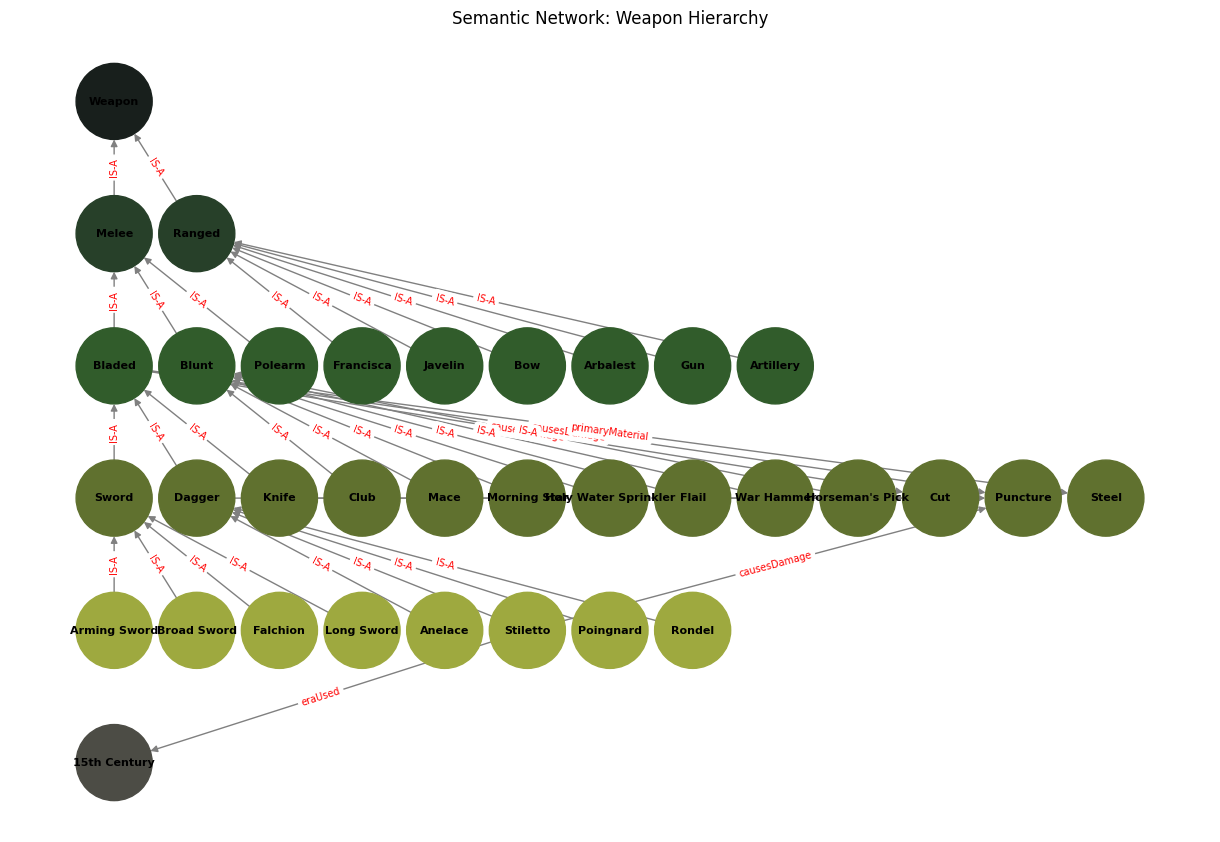

In [19]:
# Create new network object (Level 0)
weapons_net = SemanticNetwork(root_node="Weapon")

# Add weapons to the hierarchy
# Level 1
weapons_net.add_relation("Melee", "Weapon")
weapons_net.add_relation("Ranged", "Weapon")

# Level 2
weapons_net.add_relation("Bladed", "Melee")
weapons_net.add_relation("Blunt", "Melee")
weapons_net.add_relation("Polearm", "Melee")

weapons_net.add_relation("Francisca", "Ranged")
weapons_net.add_relation("Javelin", "Ranged")
weapons_net.add_relation("Bow", "Ranged")
weapons_net.add_relation("Arbalest", "Ranged")
weapons_net.add_relation("Gun", "Ranged")
weapons_net.add_relation("Artillery", "Ranged")

# Level 3
weapons_net.add_relation("Sword", "Bladed")
weapons_net.add_relation("Dagger", "Bladed")
weapons_net.add_relation("Knife", "Bladed")

weapons_net.add_relation("Club", "Blunt")
weapons_net.add_relation("Mace", "Blunt")
weapons_net.add_relation("Morning Star", "Blunt")
weapons_net.add_relation("Holy Water Sprinkler", "Blunt")
weapons_net.add_relation("Flail", "Blunt")
weapons_net.add_relation("War Hammer", "Blunt")
weapons_net.add_relation("Horseman's Pick", "Blunt")

# Level 4
weapons_net.add_relation("Arming Sword", "Sword")
weapons_net.add_relation("Broad Sword", "Sword")
weapons_net.add_relation("Falchion", "Sword")
weapons_net.add_relation("Long Sword", "Sword")

weapons_net.add_relation("Anelace", "Dagger") 
weapons_net.add_relation("Stiletto", "Dagger") 
weapons_net.add_relation("Poingnard", "Dagger") 
weapons_net.add_relation("Rondel", "Dagger") 
#weapons_net.add_relation("Colonel Blood's Dagger", "Stiletto", "INSTANCE-OF") # Level 5




# 3. Define Properties and Overrides
weapons_net.add_property("Bladed", "Cut", "causesDamage")
weapons_net.add_property("Bladed", "Puncture", "causesDamage")
weapons_net.add_property("Bladed", "Steel", "primaryMaterial")

weapons_net.add_property("Dagger", "Puncture", "causesDamage")
weapons_net.add_property("Knife", "Cut", "causesDamage")

weapons_net.add_property("Stiletto", "Puncture", "causesDamage") # The Override
weapons_net.add_property("Stiletto", "15th Century", "eraUsed")

# 4. Generate Output
print(weapons_net.generate_report())
weapons_net.draw()